In [7]:
# with the feedback added 
import h5py
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend
from scipy.interpolate import interp1d
import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint_adjoint
import gc
import mne
import time
import sys
import os
from torchdiffeq import odeint

def preprocess_signal(signal, fs=1000, lowcut=1.5, highcut=20):
    detrended = detrend(signal)
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(4, [low, high], btype='band')
    filtered = filtfilt(b, a, detrended)
    normalized = (filtered - np.mean(filtered)) / np.std(filtered)
    return normalized

def simulate_coupled_oscillators(T=4, dt=1/100, alpha=1.0, omega1=5.01, omega2=5.1, A_init=0.0001, theta_init=np.pi, n=1.0):
    """
    Simulates two coupled Stuart-Landau oscillators to generate a synthetic input signal.
    """
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    # Pre-allocate arrays
    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2

        # Calculate coupling terms
        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))

        # Update amplitudes (r) and phases (phi)
        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2 / (r1 + 1e-9) * np.sin(theta12 + n * (phi2 - phi1))
        dphi2 = omega2 + A21 * r1 / (r2 + 1e-9) * np.sin(theta21 + n * (phi1 - phi2))

        # Euler integration step
        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    return np.stack((R1 * np.cos(Phi1), R1 * np.sin(Phi1), R2 * np.cos(Phi2), R2 * np.sin(Phi2)), axis=1)

def get_random_frequencies(num_regions, osc_per_region, low=1, high=20, seed=None):
    if seed is not None:
        np.random.seed(seed)
    total_oscillators = num_regions * osc_per_region
    freqs_hz = np.random.uniform(low, high, total_oscillators)
    return 2 * np.pi * freqs_hz

def expand_structural_connectivity(Sc_region, osc_per_region, intra_value=0.0001, seed=None):
    if seed is not None:
        np.random.seed(seed)
    num_regions = Sc_region.shape[0]
    N = num_regions * osc_per_region
    Sc_full = np.zeros((N, N))
    for i in range(num_regions):
        for j in range(num_regions):
            start_i, end_i = i * osc_per_region, (i + 1) * osc_per_region
            start_j, end_j = j * osc_per_region, (j + 1) * osc_per_region
            if i == j:
                Sc_full[start_i:end_i, start_j:end_j] = intra_value
            else:
                rand_block = np.random.rand(osc_per_region, osc_per_region)
                rand_block *= Sc_region[i, j] / (rand_block.sum() + 1e-9)
                Sc_full[start_i:end_i, start_j:end_j] = rand_block
    np.fill_diagonal(Sc_full, 0.0)
    return Sc_full

def reset_weights(m):
    if hasattr(m, 'reset_parameters'):
        m.reset_parameters()

def train_heart_model(ecg_signal, device, time_sec):

    model = HeartModel().to(device)
    heart_osc_layer = HeartOscillatorLayer(fs=100, device=device).to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)  # no heart_osc_layer
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=500
    )
    criterion = nn.MSELoss()

    T_train = int(time_sec * 100)

    target = torch.tensor(
        ecg_signal[::10], dtype=torch.float32
    ).unsqueeze(1).to(device)

    losses = []
    with torch.no_grad():
        sim_input = heart_osc_layer(T_train, modulation=None)  

    for epoch in range(15000): # differentiable
        pred = model(sim_input)
        loss = criterion(pred, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step(loss.item())

        losses.append(loss.item())

        if (epoch+1) % 2500 == 0:
            print(epoch+1, loss.item())

    return model, heart_osc_layer, losses


def train_mlp_on_frozen_brain(
        trained_heart_model,
        heart_osc_layer,
        initial_brain_params,
        Sc_reduced_osc,
        N,
        D_function,
        t,
        device,t_sec):

    print("\n--- Stage 2: ECG → OscillatorLayer → Brain Training ---")

    ecg_to_osc_mlp = ECGToOscillatorMLP(
        ecg_dim=50,
        N_VNS=18,
        hidden_dim=64,
        output_dim=N,
        device=device
    ).to(device)

    optimizer = torch.optim.Adam(
        ecg_to_osc_mlp.parameters(),
        lr=5e-3
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.3,
        patience=10,
        threshold=1e-3,
        cooldown=5,
        min_lr=1e-5
    )

    criterion = CorrelationLoss()

    with torch.no_grad():
        T_steps = int(t_sec * 100)
        sim_input = heart_osc_layer(T_steps, modulation=None)
        hidden_repr = trained_heart_model.get_features(sim_input)# (T_steps, feature_dim)

    D_true = torch.tensor(D_function(t), device=device, dtype=torch.float32)
    losses = []
    D_full_train = D_function(t)

    model = TorchRevHopfNetwork(
        mu=1.0,
        eta_omega=0.0,
        eta_alpha=0.0,
        eta_theta=0.0,
        D_full=D_full_train,
        N=N,
        Sc=Sc_reduced_osc,
        brain_drive_full=None,
        fs=100,
        fixed_params=initial_brain_params,
        device=device
    )

    for epoch in range(300):

        raw_drive = ecg_to_osc_mlp(hidden_repr)  
        brain_drive_full = (raw_drive)
        model.ode_func.brain_drive_full = brain_drive_full

        r, phi, theta, omega, alpha, _ = model.solve(
            initial_brain_params['r'],
            initial_brain_params['phi'],
            t,
            use_adjoint=False
        )

        P_out = torch.sum(alpha * r * torch.cos(phi), dim=1)
        settle = int(0.1 * model.ode_func.fs)   # ignore first 300 ms
        pred = P_out[settle:]
        target = D_true[settle:]

        corr_loss = criterion(pred, target)
        mse_loss = torch.mean((pred - target) ** 2)

        loss = mse_loss
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ecg_to_osc_mlp.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step(loss.item())

        losses.append(loss.item())

        if (epoch + 1) % 10 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(
                f"Epoch {epoch+1}, "
                f"Loss: {loss.item():.6f}, "
                f"LR: {current_lr:.3e}"
            )


    return ecg_to_osc_mlp, losses

def train_feedback_stage(
        trained_heart_model,
        trained_mlp_model,
        heart_osc_layer,
        final_brain_params,
        Sc_reduced_osc,
        N,
        D_full_func,
        t_train,
        ecg_train_processed,
        device,
        num_epochs=1000
):
    print("\n--- Stage 4: Brain→Heart Feedback Training ---")

    feedback_mlp = BrainToHeartFeedbackMLP(
        brain_dim=N,
        N_VNS=12,
        hidden_dim=64,
        device=device
    ).to(device)


    optimizer = torch.optim.Adam(
        list(feedback_mlp.parameters()) + list(heart_osc_layer.parameters()),
        lr=1e-3
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=15, min_lr=1e-5
    )
    criterion = CorrelationLoss()

    T_train = len(t_train)
    target_ecg = torch.tensor(
        ecg_train_processed[::10], dtype=torch.float32, device=device
    ).unsqueeze(1)

    D_full_train = D_full_func(t_train)

    losses = []

    for epoch in range(num_epochs):

        # Step 1 — frozen: get brain drive
        with torch.no_grad():
            # use unmodulated sim to get stable brain drive each epoch
            sim_plain = heart_osc_layer(T_train, modulation=None).detach()
            hidden = trained_heart_model.get_features(sim_plain)
            brain_drive = trained_mlp_model(hidden)

        # Step 2 — frozen: run brain ODE → rcos_phi
        with torch.no_grad():
            model_brain = TorchRevHopfNetwork(
                mu=1.0,
                D_full=D_full_train,
                N=N,
                Sc=Sc_reduced_osc,
                brain_drive_full=brain_drive,
                fs=100,
                fixed_params=final_brain_params,
                device=device
            )
            r_br, phi_br, _, _, _, _ = model_brain.solve(
                final_brain_params['r'],
                final_brain_params['phi'],
                t_train,
                use_adjoint=False
            )
            rcos_phi = (r_br * torch.cos(phi_br)).detach()  # (T, N)

        # Step 3 — feedback MLP: brain state → modulation (GRADIENTS FLOW FROM HERE)
        modulation = feedback_mlp(rcos_phi)  # (T, 2)

        # Step 4 — differentiable heart oscillator sim with modulation
        sim_modulated = heart_osc_layer(T_train, modulation=modulation)  # (T, 4)

        # Step 5 — predict ECG
        pred_ecg = trained_heart_model(sim_modulated)  # (T, 1)

        # Step 6 — loss
        loss = criterion(pred_ecg.squeeze(), target_ecg.squeeze())

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(feedback_mlp.parameters()) + list(heart_osc_layer.parameters()),
            max_norm=1.0
        )
        optimizer.step()
        scheduler.step(loss.item())
        losses.append(loss.item())

        if (epoch + 1) % 20 == 0:
            lr = optimizer.param_groups[0]['lr']
            print(f"Feedback Epoch {epoch+1}/{num_epochs} | Loss: {loss.item():.6f} | LR: {lr:.3e}")

    print("--- Stage 4 Finished ---")
    return feedback_mlp,losses

In [8]:


# classes 
class HeartModel(nn.Module):
    """A simple MLP to map oscillator states to an ECG signal."""
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, feature_dim),
            nn.SiLU()
        )
        self.output_layer = nn.Linear(feature_dim, output_dim)

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.output_layer(features)
    
    def get_features(self, x):
        return self.feature_extractor(x)
    
class HeartOscillatorODEFunc(nn.Module):
    def __init__(self, alpha=1.0, omega1=5.01, omega2=5.1,
                 A_init=0.0001, theta_init=np.pi, n=1.0, fs=100):
        super().__init__()
        self.alpha = alpha
        self.A12 = A_init
        self.A21 = A_init
        self.n = n
        self.fs = fs
        self.modulation = None

        # learnable parameters
        self.omega1 = omega1
        self.omega2 = omega2    

        # fixed buffers — on correct device automatically
        self.register_buffer("theta12", torch.tensor(theta_init, dtype=torch.float32))
        self.register_buffer("theta21", torch.tensor(theta_init, dtype=torch.float32))

    def forward(self, t, state):
        r1, phi1, r2, phi2 = state[0], state[1], state[2], state[3]

        r1 = torch.clamp(r1, 1e-6, 5.0)
        r2 = torch.clamp(r2, 1e-6, 5.0)

        omega1 = self.omega1
        omega2 = self.omega2

        coupling12 = self.A12 * r2 * torch.cos(self.theta12 + self.n * (phi2 - phi1))
        coupling21 = self.A21 * r1 * torch.cos(self.theta21 + self.n * (phi1 - phi2))

        if self.modulation is not None:
            t_idx = torch.clamp((t * self.fs).long(), 0, self.modulation.shape[0] - 1)
            mod = self.modulation[t_idx]
            dr1 = (self.alpha - r1**2) * r1 + coupling12 + 0.1 * mod[0]
            dr2 = (self.alpha - r2**2) * r2 + coupling21 + 0.1 * mod[1]
        else:
            dr1 = (self.alpha - r1**2) * r1 + coupling12
            dr2 = (self.alpha - r2**2) * r2 + coupling21

        dphi1 = omega1 + self.A12 * (r2 / r1) * torch.sin(self.theta12 + self.n * (phi2 - phi1))
        dphi2 = omega2 + self.A21 * (r1 / r2) * torch.sin(self.theta21 + self.n * (phi1 - phi2))

        return torch.stack([dr1, dphi1, dr2, dphi2])


class HeartOscillatorLayer(nn.Module):
    """
    Differentiable version of simulate_coupled_oscillators.
    Input:  modulation (T, 2) or None
    Output: (T, 4) — [r1·cos(φ1), r1·sin(φ1), r2·cos(φ2), r2·sin(φ2)]
    """
    def __init__(self, alpha=1.0, omega1=5.01, omega2=5.1,
                 A_init=0.0001, theta_init=np.pi, n=1.0, fs=100, device="cpu"):
        super().__init__()
        self.fs = fs
        self.device = device
        self.ode_func = HeartOscillatorODEFunc(
            alpha=alpha, omega1=omega1, omega2=omega2,
            A_init=A_init, theta_init=theta_init, n=n, fs=fs
        )
        self.register_buffer(
            "y0",
            torch.tensor([1.0, 0.0, 1.0, 0.0], dtype=torch.float32)
        )

    def forward(self, T, modulation=None):
        # modulation: (T, 2) tensor or None
        self.ode_func.modulation = modulation

        t_eval = torch.arange(0, T, dtype=torch.float32, device=self.y0.device) / self.fs

        sol = odeint(self.ode_func, self.y0, t_eval, method="rk4")  # (T, 4)

        r1  = torch.clamp(sol[:, 0], 1e-6, 5.0)
        phi1 = sol[:, 1]
        r2  = torch.clamp(sol[:, 2], 1e-6, 5.0)
        phi2 = sol[:, 3]

        return torch.stack([
            r1 * torch.cos(phi1),
            r1 * torch.sin(phi1),
            r2 * torch.cos(phi2),
            r2 * torch.sin(phi2)
        ], dim=1)  # (T, 4)
    
class BrainToHeartMLP(nn.Module):
    """
    Brain oscillators → MLP → OscillatorLayer → heart drive
    """
    def __init__(self, brain_dim, N_heart_osc, hidden_dim=64, device="cuda"):
        super().__init__()

        self.pre_osc = nn.Sequential(
            nn.Linear(brain_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, N_heart_osc)
        )

        self.osc_layer = OscillatorLayer(N_osc=N_heart_osc, fs=100, device=device)

        self.post_osc = nn.Sequential(
            nn.Linear(N_heart_osc, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1)  # scalar heart drive
        )

    def forward(self, brain_state):
        x = self.pre_osc(brain_state)
        osc_hidden = self.osc_layer(x)
        heart_drive = self.post_osc(osc_hidden)
        return heart_drive
    
class OscillatorODEFunc(nn.Module):
    def __init__(self, N_osc, mu, k, omega, C, theta, fs=100, device="cpu"):  # ✅ fs added
        super().__init__()
        self.N_osc = N_osc
        self.fs = fs          # ✅ set here instead of patched externally
        self.mu = mu
        self.k = k

        self.omega=omega
        self.register_buffer("C", C)
        self.register_buffer("theta", theta)
        self.r_min = 0.001
        self.r_max = 3.0
        self.phase_clip = 2 * np.pi
        self.input_f = None

    def forward(self, t, state):
        N = self.N_osc
        r   = state[:N]
        phi = state[N:2*N]

        t_idx = torch.clamp(
            (t * self.fs).long(),
            0,
            self.input_f.shape[0] - 1
        )

        input_f = 0.05 * self.input_f[t_idx]  # ✅ shape (N,) — removed unsqueeze(-1)

        # ✅ clamp omega for numerical stability
        omega = torch.clamp(self.omega, 2 * np.pi * 1.0, 2 * np.pi * 20.0)

        r_safe = torch.clamp(r, self.r_min, self.r_max)

        # ✅ explicit 2D broadcasting — clearer than .T on a 1D tensor
        omega_i = omega.unsqueeze(1)    # (N, 1)
        omega_j = omega.unsqueeze(0)    # (1, N)
        phi_i   = phi.unsqueeze(1)      # (N, 1)
        phi_j   = phi.unsqueeze(0)      # (1, N)
        r_safe_i = r_safe.unsqueeze(1)  # (N, 1)
        r_safe_j = r_safe.unsqueeze(0)  # (1, N)

        phase_term = torch.clamp(
            phi_j / omega_j - phi_i / omega_i + self.theta / (omega_i * omega_j),
            -self.phase_clip,
            self.phase_clip
        )  # (N, N)

        coupling_r   = self.k * torch.sum(self.C * r_safe_j * torch.cos(phase_term), dim=1)  # (N,)
        coupling_phi = self.k * torch.sum(self.C * (r_safe_j / r_safe_i) * torch.sin(phase_term), dim=1)  # (N,)

        dr_dt   = (self.mu - r_safe ** 2) * r_safe + coupling_r + input_f  # (N,)
        dphi_dt = omega + coupling_phi                                       # (N,)

        return torch.cat([dr_dt, dphi_dt])  # (2N,) — ✅ no .flatten() needed, already 1D


class OscillatorLayer(nn.Module):
    def __init__(self, N_osc=16, fs=100, device="cpu",
                 coupling_sparsity=0.3, seed=42):
        super().__init__()

        self.N_osc = N_osc
        self.fs = fs
        self.dt = 1.0 / fs

        torch.manual_seed(seed)

        freqs = 2.0 + torch.rand(N_osc, device=device) * 8.0

        # ✅ omega is now a learnable parameter
        self.omega_param = nn.Parameter(2 * torch.pi * freqs)
        # leave mu and k as buffers — stable fixed dynamics
        self.register_buffer("mu_param", torch.tensor(1.0, device=device))
        self.register_buffer("k_param",  torch.tensor(0.05, device=device))

        mask  = torch.rand(N_osc, N_osc, device=device) > coupling_sparsity
        mask.fill_diagonal_(False)
        C_val = torch.rand(N_osc, N_osc, device=device) * 0.02
        self.register_buffer("C_buffer",     C_val * mask.float())
        self.register_buffer("theta_buffer", torch.zeros(N_osc, N_osc, device=device))

        self.ode_func = OscillatorODEFunc(
            N_osc=N_osc,
            mu=self.mu_param,
            k=self.k_param,
            omega=self.omega_param,
            C=self.C_buffer,
            theta=self.theta_buffer,
            fs=fs,           # ✅ passed in constructor
            device=device
        )

        # ✅ better initial r — avoids lower clamp boundary
        self.register_buffer("initial_r",   torch.ones(N_osc, device=device) * 0.5)
        self.register_buffer("initial_phi", torch.zeros(N_osc, device=device))

        self.r_min = 0.01
        self.r_max = 2.0

    def forward(self, input_features):  # input_features: (T, N_osc)
        T = input_features.shape[0]

        # ✅ fs no longer needs to be set here — it's fixed at init
        self.ode_func.input_f = input_features

        y0 = torch.cat([self.initial_r, self.initial_phi])  # (2N,)

        t_eval = torch.arange(0, T, device=input_features.device, dtype=torch.float32) / self.fs

        sol = odeint(self.ode_func, y0, t_eval, method="rk4")  # (T, 2N)

        r   = torch.clamp(sol[:, :self.N_osc],  self.r_min, self.r_max)
        phi = sol[:, self.N_osc:]

        return (r * torch.cos(phi))  # (T, N_osc)


class ECGToOscillatorMLP(nn.Module):
    """ECG → MLP → OscillatorLayer → MLP → Brain drive [N]"""
    def __init__(self, ecg_dim=50, N_VNS=18, hidden_dim=64, output_dim=16, device="cuda"):
        super().__init__()
        self.pre_osc = nn.Sequential(
            nn.Linear(ecg_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, N_VNS)
        )
        self.osc_layer = OscillatorLayer(
            N_osc=N_VNS,
            fs=100,
            device=device,
            coupling_sparsity=0.3,
            seed=42
        )
        self.post_osc = nn.Sequential(
            nn.Linear(N_VNS, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, ecg_features):  # (T, ecg_dim)
        # ✅ only normalize when we have multiple timesteps — avoids std=0 crash
        if ecg_features.dim() == 1:
            ecg_features = ecg_features.unsqueeze(0)

        if ecg_features.shape[0] > 1:
            ecg_features = (ecg_features - ecg_features.mean(dim=0, keepdim=True)) / (
                ecg_features.std(dim=0, keepdim=True) + 1e-6
            )

        pre        = self.pre_osc(ecg_features)   # (T, N_VNS)
        osc_hidden = self.osc_layer(pre)           # (T, N_VNS)
        brain_drive = self.post_osc(osc_hidden)    # (T, output_dim)

        if brain_drive.shape[0] == 1:
            return brain_drive.squeeze(0)
        return brain_drive

class ODEFuc(nn.Module):
    def __init__(self, mu, D_full, N, Sc,
                 omega0, alpha0, theta0,
                 brain_drive_full=None,
                 fs=100,
                 fixed_params=None):

        super().__init__()
        self.mu = mu
        self.register_buffer("D_full", torch.tensor(D_full, dtype=torch.float32))
        self.N = N
        self.fs = fs
        self.register_buffer('Sc', torch.tensor(Sc, dtype=torch.float32))
        self.brain_drive_full = brain_drive_full
        self.fixed_params = fixed_params

        if self.fixed_params is not None:
            # Stage 2 — freeze everything
            self.register_buffer('theta_fixed', torch.tensor(fixed_params['theta'], dtype=torch.float32))
            self.register_buffer('omega_fixed', torch.tensor(fixed_params['omega'], dtype=torch.float32))
            self.register_buffer('alpha_fixed', torch.tensor(fixed_params['alpha'], dtype=torch.float32))
        else:
            # Stage 1 — omega, alpha, theta are learnable parameters
            self.omega_param = nn.Parameter(torch.tensor(omega0, dtype=torch.float32))
            self.alpha_param = nn.Parameter(torch.tensor(alpha0, dtype=torch.float32))
            self.theta_param = nn.Parameter(torch.tensor(theta0, dtype=torch.float32))

    def forward(self, t, state):
        N = self.N

        if self.fixed_params is not None:
            r   = state[:N]
            phi = state[N:2*N]
            omega = self.omega_fixed
            alpha = self.alpha_fixed
            theta = self.theta_fixed
        else:
            # Only r and phi are in the ODE state now
            r   = state[:N]
            phi = state[N:2*N]
            omega = self.omega_param
            alpha = self.alpha_param
            theta = self.theta_param

        omega_safe = torch.clamp(omega, 2 * np.pi * 0.5, 2 * np.pi * 20)
        r     = torch.clamp(r, 1e-1, 4.0)
        alpha = torch.clamp(alpha, -3.0, 3.0)

        phase_diff = torch.clamp(
            phi[None, :] / omega_safe[None, :] -
            phi[:, None] / omega_safe[:, None] +
            theta / (omega_safe[:, None] * omega_safe[None, :]),
            -1e2, 1e2
        )

        t_idx_D = torch.clamp((t * self.fs).long(), 0, self.D_full.shape[0] - 1)
        D = self.D_full[t_idx_D]

        P = torch.sum(alpha * r * torch.cos(phi % (2 * np.pi)))
        e = D - P

        if self.brain_drive_full is not None:
            t_idx_drive = torch.clamp((t * self.fs).long(), 0, self.brain_drive_full.shape[0] - 1)
            ecg_input = self.brain_drive_full[t_idx_drive]
        else:
            ecg_input = torch.zeros(N, device=state.device)

        coupling_r   = torch.sum(self.Sc * r[None, :] * torch.cos(phase_diff), dim=1)
        coupling_phi = torch.sum(self.Sc * (r[None, :] / r[:, None]) * torch.sin(phase_diff), dim=1)

        drdt   = (self.mu - r**2) * r + coupling_r   + e * torch.cos(phi) + 0.7*ecg_input
        dphidt = omega_safe + coupling_phi - (e / r) * torch.sin(phi) 
        
        return torch.cat([drdt.flatten(), dphidt.flatten()])


class TorchRevHopfNetwork:
    def __init__(self, mu, D_full, N, Sc,
                 omega0=None, alpha0=None, theta0=None,
                 brain_drive_full=None,
                 fs=100,
                 fixed_params=None,
                 device="cuda",
                 eta_omega=0.0, eta_alpha=0.0, eta_theta=0.0):

        self.device = torch.device(device)
        self.N = N

        self.ode_func = ODEFuc(
            mu=mu,
            D_full=D_full,
            N=N,
            Sc=Sc,
            omega0=omega0,
            alpha0=alpha0,
            theta0=theta0,
            brain_drive_full=brain_drive_full,
            fs=fs,
            fixed_params=fixed_params
        ).to(self.device)

    def solve(self, r0, phi0, t_eval, use_adjoint=False):
        # State is now just [r, phi] — omega/alpha/theta are parameters
        y0 = torch.tensor(
            np.concatenate([r0, phi0]),
            device=self.device,
            dtype=torch.float32
        )

        t_eval_tensor = torch.tensor(t_eval, device=self.device, dtype=torch.float32)

        if use_adjoint:
            sol = odeint_adjoint(
                self.ode_func, y0, t_eval_tensor,
                method="rk4",
                adjoint_params=tuple(self.ode_func.parameters())
            )
        else:
            sol = odeint(self.ode_func, y0, t_eval_tensor, method="rk4")

        N = self.N
        r   = sol[:, :N]
        phi = sol[:, N:2*N]

        # Return omega/alpha/theta expanded to (T, N) for downstream compatibility
        if self.ode_func.fixed_params is not None:
            omega = self.ode_func.omega_fixed.unsqueeze(0).expand(sol.shape[0], N)
            alpha = self.ode_func.alpha_fixed.unsqueeze(0).expand(sol.shape[0], N)
            theta = self.ode_func.theta_fixed.unsqueeze(0).expand(sol.shape[0], N, N)
        else:
            omega = self.ode_func.omega_param.unsqueeze(0).expand(sol.shape[0], N)
            alpha = self.ode_func.alpha_param.unsqueeze(0).expand(sol.shape[0], N)
            theta = self.ode_func.theta_param.unsqueeze(0).expand(sol.shape[0], N, N)

        rcos_phi = torch.sum(r * torch.cos(phi), dim=1)
        return r, phi, theta, omega, alpha, rcos_phi


def pre_train_brain_model(eeg_processed, Sw_all, target_idx, non_zero_indices_per_row, t, D_function, device):
    print("\n--- Stage 1: Brain Pre-training (backprop) ---")
    connected_indices = np.unique(np.append(non_zero_indices_per_row[target_idx], target_idx))
    N_reduced_regions = len(connected_indices)
    osc_per_region = 4
    N = N_reduced_regions * osc_per_region

    Sc_reduced_regional = Sw_all[np.ix_(connected_indices, connected_indices)]
    Sc_reduced_osc = expand_structural_connectivity(Sc_reduced_regional, osc_per_region, seed=42)
    Sc_reduced_osc = Sc_reduced_osc * 10.0 
    print("N:", N)
    print("N_reduced_regions:", N_reduced_regions)
    print("Sc_reduced_osc sparsity:", (Sc_reduced_osc == 0).mean())
    print("Sc_reduced_osc max:", Sc_reduced_osc.max())
    print("Sc_reduced_osc mean nonzero:", Sc_reduced_osc[Sc_reduced_osc > 0].mean())

    omega_full = get_random_frequencies(68, osc_per_region, low=1, high=20, seed=42)
    omega0 = np.concatenate([omega_full[i * osc_per_region:(i + 1) * osc_per_region] for i in connected_indices])
    alpha0 = np.ones(N) * (1.0 / np.sqrt(N))
    theta_random = np.pi * (2 * np.random.rand(N, N) - 1)
    theta0 = theta_random - theta_random.T

    r0   = np.ones(N)
    phi0 = np.zeros(N)

    D_full_train = D_function(t)

    model = TorchRevHopfNetwork(
        mu=1.0,
        D_full=D_full_train,
        N=N,
        Sc=Sc_reduced_osc,
        omega0=omega0,
        alpha0=alpha0,
        theta0=theta0,
        fs=100,
        fixed_params=None,   # None = Stage 1, params are learnable
        device=device
    )

    optimizer = torch.optim.Adam([
        {'params': [model.ode_func.omega_param], 'lr': 1e-2},
        {'params': [model.ode_func.alpha_param], 'lr': 1e-2},
        {'params': [model.ode_func.theta_param], 'lr': 1e-3},  # theta slower — it's N×N
    ])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=20, min_lr=1e-5
    )

    criterion = CorrelationLoss()
    D_true = torch.tensor(D_full_train, device=device, dtype=torch.float32)
    settle = 10
    losses = []

    for epoch in range(300):
        # No torch.no_grad() — we need gradients through the ODE
        r, phi, theta, omega, alpha, _ = model.solve(r0, phi0, t, use_adjoint=False)

        P_out = torch.sum(alpha * r * torch.cos(phi), dim=1)
        corr_loss = criterion(P_out[settle:], D_true[settle:])
        P_std_val = torch.std(P_out[settle:])
        D_std_val = torch.std(D_true[settle:])
        scale_loss = (P_std_val / D_std_val - 1.0) ** 2
        alpha_penalty = torch.mean(torch.relu(0.3 - model.ode_func.alpha_param ** 2))
        loss = corr_loss + 0.1 * scale_loss + 0.2 * alpha_penalty
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [model.ode_func.omega_param,
             model.ode_func.alpha_param,
             model.ode_func.theta_param],
            max_norm=1.0
        )
        optimizer.step()

        # Warm-start r and phi only — omega/alpha/theta are now parameters
        with torch.no_grad():
            r0   = r[-1].cpu().numpy()
            phi0 = (phi[-1].cpu().numpy()) % (2 * np.pi)

        losses.append(loss.item())

        if (epoch + 1) % 10 == 0:
            P_scale = torch.std(P_out[settle:]).item()
            D_scale = torch.std(D_true[settle:]).item()
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Brain Epoch {epoch+1}/300, Loss: {loss.item():.6f} | "
                  f"P_std: {P_scale:.4f} D_std: {D_scale:.4f} | LR: {current_lr:.2e}")
        
        scheduler.step(loss.item())

    final_params = {
        'r':     r[-1].detach().cpu().numpy(),
        'phi':   (phi[-1].detach().cpu().numpy()) % (2 * np.pi),
        'theta': model.ode_func.theta_param.detach().cpu().numpy(),
        'omega': model.ode_func.omega_param.detach().cpu().numpy(),
        'alpha': model.ode_func.alpha_param.detach().cpu().numpy()
    }
    return final_params, Sc_reduced_osc, N, losses
class CorrelationLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, pred, target):

        pred = pred - torch.mean(pred)
        target = target - torch.mean(target)

        numerator = torch.sum(pred * target)

        denominator = torch.sqrt(
            torch.sum(pred ** 2) * torch.sum(target ** 2) + self.eps
        )

        corr = numerator / denominator

        loss = 1 - corr
        return loss
    

class BrainToHeartFeedbackMLP(nn.Module):
    """Brain oscillator outputs (r·cos(φ)) → OscillatorLayer → 2 heart modulation channels"""
    def __init__(self, brain_dim, N_VNS=12, hidden_dim=64, device="cuda"):
        super().__init__()
        self.pre_osc = nn.Sequential(
            nn.Linear(brain_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, N_VNS)
        )
        self.osc_layer = OscillatorLayer(
            N_osc=N_VNS,
            fs=100,
            device=device,
            coupling_sparsity=0.3,
            seed=99
        )
        self.post_osc = nn.Sequential(
            nn.Linear(N_VNS, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, 2)  # one channel per heart oscillator
        )

    def forward(self, rcos_phi):  # (T, N_brain)
        if rcos_phi.shape[0] > 1:
            rcos_phi = (rcos_phi - rcos_phi.mean(dim=0, keepdim=True)) / (
                rcos_phi.std(dim=0, keepdim=True) + 1e-6
            )
        pre        = self.pre_osc(rcos_phi)    # (T, N_VNS)
        osc_hidden = self.osc_layer(pre)        # (T, N_VNS)
        out        = self.post_osc(osc_hidden)  # (T, 2)
        return out

Opening raw data file /home/shobs/Desktop/DDP/transdef_mf2pt2_rest_raw.fif...
    Range : 114000 ... 680999 =    114.000 ...   680.999 secs
Ready.
Reading 0 ... 566999  =      0.000 ...   566.999 secs...
--- Using device: cuda ---
2500 0.30802440643310547
5000 0.09628139436244965
7500 0.05700287967920303
10000 0.047448545694351196
12500 0.040328510105609894
15000 0.03841172158718109

--- Stage 1: Brain Pre-training (backprop) ---
N: 48
N_reduced_regions: 12
Sc_reduced_osc sparsity: 0.020833333333333332
Sc_reduced_osc max: 0.12687849245062027
Sc_reduced_osc mean nonzero: 0.006822014351601968
Brain Epoch 10/300, Loss: 0.915796 | P_std: 0.7130 D_std: 1.0540 | LR: 1.00e-02
Brain Epoch 20/300, Loss: 0.840132 | P_std: 0.7004 D_std: 1.0540 | LR: 1.00e-02
Brain Epoch 30/300, Loss: 0.859982 | P_std: 0.6827 D_std: 1.0540 | LR: 1.00e-02
Brain Epoch 40/300, Loss: 0.694717 | P_std: 0.7607 D_std: 1.0540 | LR: 1.00e-02
Brain Epoch 50/300, Loss: 0.696594 | P_std: 0.7693 D_std: 1.0540 | LR: 1.00e-02
Br

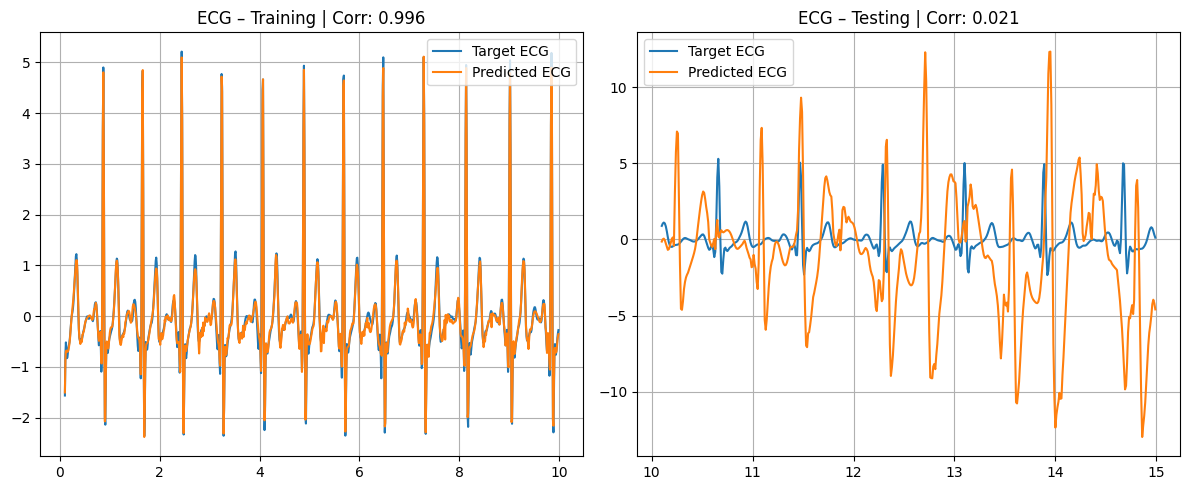

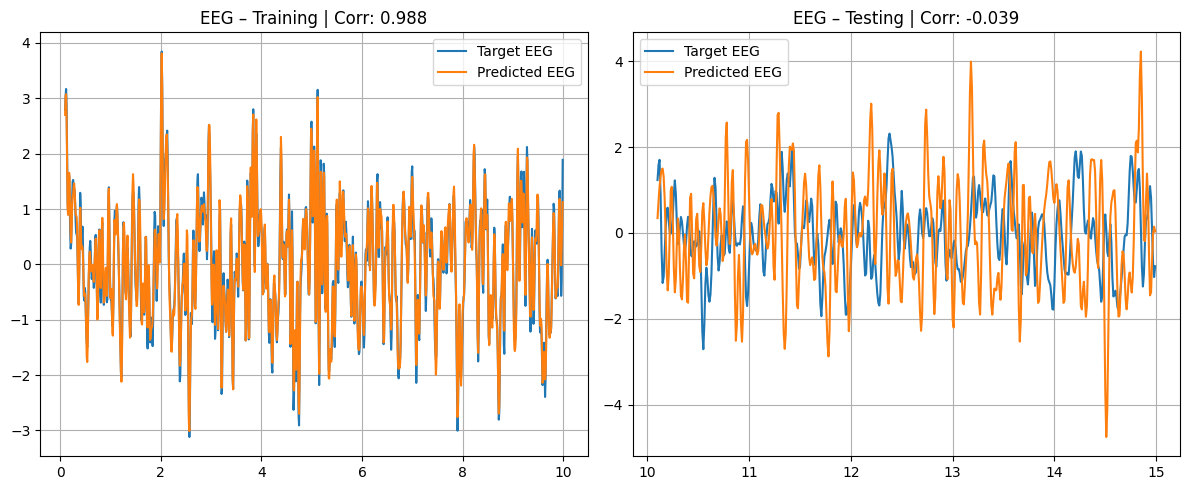

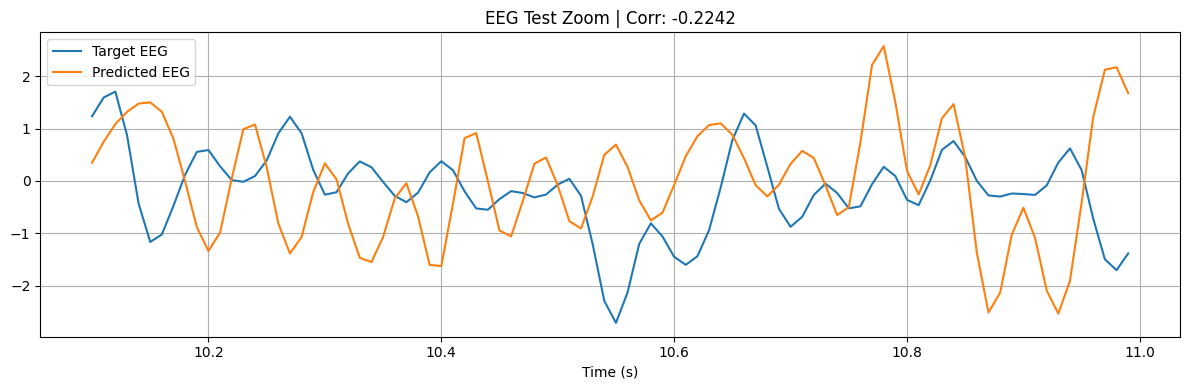

In [9]:
# ===============================
# LOAD DATA
# ===============================

file_raw = '/home/shobs/Desktop/DDP/transdef_mf2pt2_rest_raw.fif'
raw = mne.io.read_raw_fif(file_raw, preload=True)

mat = loadmat("/home/shobs/Desktop/DDP/scout_id_309.mat")
sc_data = loadmat('/home/shobs/Desktop/DDP/SC_CC120309-27.mat')
sc_matrix = sc_data["sc"]

max_val = np.max(sc_matrix)
Sw_all = (sc_matrix / max_val) * 0.2
percentile = 60
thr = np.percentile(Sw_all, percentile)

Sw_sparse = Sw_all.copy()
Sw_sparse[Sw_sparse < thr] = 0
non_zero_indices_per_row = [
    np.nonzero(Sw_sparse[i])[0]
    for i in range(Sw_sparse.shape[0])
]

fs_raw   = 1000
fs_model = 100
train_sec  = 10
test_sec   = 5
total_sec  = train_sec + test_sec

start_idx     = 2000
total_samples = total_sec * fs_raw

# ===============================
# SLICE FULL DURATION AT ONCE
# ===============================

full_slice = slice(start_idx, start_idx + total_samples)

ecg_full = -raw[322, full_slice][0][0]
eeg_full =  mat['Value'][:, full_slice]

# ===============================
# PREPROCESS FULL SIGNALS
# ===============================

ecg_full_processed = preprocess_signal(ecg_full, fs=1000, lowcut=1.5, highcut=20)

eeg_full_processed = np.array([
    preprocess_signal(row, fs=1000, lowcut=0.5, highcut=20)
    for row in eeg_full
])

# ===============================
# SPLIT INTO TRAIN / TEST
# ===============================

train_samples_raw = train_sec * fs_raw
train_samples_model = train_sec * fs_model

ecg_train_processed = ecg_full_processed[:train_samples_raw]
ecg_test_processed  = ecg_full_processed[train_samples_raw:]

eeg_train_processed = eeg_full_processed[:, :train_samples_raw]
eeg_test_processed  = eeg_full_processed[:, train_samples_raw:]

target_idx = 4

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"--- Using device: {device} ---")

# ===============================
# TIME AXES
# ===============================

t_full  = np.arange(0, total_sec,  1/fs_model)
t_train = np.arange(0, train_sec,  1/fs_model)
t_test  = np.arange(train_sec, total_sec, 1/fs_model)  # continues from train end

# Downsampled targets
target_full  = eeg_full_processed[target_idx, ::10]
target_train = target_full[:train_samples_model]
target_test  = target_full[train_samples_model:]

# Single D_function over full duration
D_full_func = interp1d(t_full, target_full,
                       kind='linear',
                       bounds_error=False,
                       fill_value=0.0)

# Convenience wrappers for train/test (t_test starts at train_sec)
D_train_func = interp1d(t_train, target_train,
                        kind='linear',
                        bounds_error=False,
                        fill_value=0.0)

# ===============================

trained_heart_model, heart_osc_layer, heart_losses = train_heart_model(
    ecg_train_processed,
    device,
    train_sec
)


# ===============================
# STAGE 2: PRETRAIN BRAIN
# ===============================

final_brain_params, Sc_reduced_osc, N, brain_losses = pre_train_brain_model(
    eeg_train_processed,
    Sw_all,
    target_idx,
    non_zero_indices_per_row,
    t_train,
    D_train_func,
    device
)



trained_mlp_model, mlp_losses = train_mlp_on_frozen_brain(
    trained_heart_model,
    heart_osc_layer,        # <-- pass through
    final_brain_params,
    Sc_reduced_osc,
    N,
    D_train_func,
    t_train,
    device,
    train_sec
)
# Stage 4 call — note heart_osc_layer is now returned
trained_feedback_mlp, feedback_losses = train_feedback_stage(
    trained_heart_model,
    trained_mlp_model,
    heart_osc_layer,
    final_brain_params,
    Sc_reduced_osc,
    N,
    D_train_func,
    t_train,
    ecg_train_processed,
    device,
    num_epochs=100
)

# Final evaluation
trained_heart_model.eval()
trained_mlp_model.eval()
trained_feedback_mlp.eval()
heart_osc_layer.eval()

T_full = len(t_full)

with torch.no_grad():
    # Get brain rcos_phi using unmodulated sim first
    sim_plain_full = heart_osc_layer(T_full, modulation=None)
    hidden_full = trained_heart_model.get_features(sim_plain_full)
    brain_drive_full = trained_mlp_model(hidden_full)

    model_for_feedback = TorchRevHopfNetwork(
        mu=1.0,
        D_full=D_full_func(t_full),
        N=N,
        Sc=Sc_reduced_osc,
        brain_drive_full=brain_drive_full,
        fs=fs_model,
        fixed_params=final_brain_params,
        device=device
    )
    r_fb, phi_fb, _, _, _, _ = model_for_feedback.solve(
        final_brain_params['r'],
        final_brain_params['phi'],
        t_full,
        use_adjoint=False
    )
    rcos_phi_full = r_fb * torch.cos(phi_fb)  # (T_full, N)

    # Feedback modulation over full duration
    modulation_full = trained_feedback_mlp(rcos_phi_full)  # (T_full, 2)

    # Differentiable sim with feedback
    sim_full_modulated = heart_osc_layer(T_full, modulation=modulation_full)

    # Final predictions
    ecg_pred_full = trained_heart_model(sim_full_modulated).cpu().numpy().flatten()
    hidden_full   = trained_heart_model.get_features(sim_full_modulated)
    brain_drive_full = trained_mlp_model(hidden_full)

    model_full = TorchRevHopfNetwork(
        mu=1.0,
        D_full=D_full_func(t_full),
        N=N,
        Sc=Sc_reduced_osc,
        brain_drive_full=brain_drive_full,
        fs=fs_model,
        fixed_params=final_brain_params,
        device=device
    )
    r_full, phi_full, _, _, alpha_full, _ = model_full.solve(
        final_brain_params['r'],
        final_brain_params['phi'],
        t_full,
        use_adjoint=False
    )
    P_full = torch.sum(
        alpha_full * r_full * torch.cos(phi_full), dim=1
    ).cpu().numpy()

ecg_pred_train = ecg_pred_full[:train_samples_model]
ecg_pred_test  = ecg_pred_full[train_samples_model:]
P_train = P_full[:train_samples_model]
P_test  = P_full[train_samples_model:]

target_ecg_train = ecg_train_processed[::10]
target_ecg_test  = ecg_test_processed[::10]
target_eeg_train = target_train
target_eeg_test  = target_test

# ===============================
# METRICS & PLOTS
# ===============================

ignore_sec     = 0.1
ignore_samples = int(ignore_sec * fs_model)

def metrics(y_true, y_pred):
    mse  = np.mean((y_true - y_pred) ** 2)
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    return mse, corr

def phase_corrected_corr(y_true, y_pred, max_lag_sec=0.5, fs=100):
    from scipy.signal import correlate
    max_lag = int(max_lag_sec * fs)
    cc   = correlate(y_true, y_pred, mode='full')
    lags = np.arange(-len(y_true)+1, len(y_true))
    best_lag = int(np.clip(lags[np.argmax(cc)], -max_lag, max_lag))
    if best_lag > 0:
        y_shifted = np.concatenate([np.zeros(best_lag), y_pred[:-best_lag]])
    elif best_lag < 0:
        y_shifted = np.concatenate([y_pred[-best_lag:], np.zeros(-best_lag)])
    else:
        y_shifted = y_pred
    corr = np.corrcoef(y_true, y_shifted)[0, 1]
    print(f"Best lag: {best_lag/fs*1000:.1f} ms | Phase-corrected corr: {corr:.4f}")
    return corr, best_lag, y_shifted

mse_ecg_train, corr_ecg_train = metrics(target_ecg_train[ignore_samples:], ecg_pred_train[ignore_samples:])
mse_ecg_test,  corr_ecg_test  = metrics(target_ecg_test[ignore_samples:],  ecg_pred_test[ignore_samples:])
mse_eeg_train, corr_eeg_train = metrics(target_eeg_train[ignore_samples:], P_train[ignore_samples:])
mse_eeg_test,  corr_eeg_test  = metrics(target_eeg_test[ignore_samples:],  P_test[ignore_samples:])

print("\n===== PERFORMANCE (First 0.1s Ignored) =====")
print(f"\nECG Train | MSE: {mse_ecg_train:.4f} | Corr: {corr_ecg_train:.4f}")
print(f"ECG Test  | MSE: {mse_ecg_test:.4f}  | Corr: {corr_ecg_test:.4f}")
print(f"\nEEG Train | MSE: {mse_eeg_train:.4f} | Corr: {corr_eeg_train:.4f}")
print(f"EEG Test  | MSE: {mse_eeg_test:.4f}  | Corr: {corr_eeg_test:.4f}")

# ECG plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(t_train[ignore_samples:], target_ecg_train[ignore_samples:], label="Target ECG")
axes[0].plot(t_train[ignore_samples:], ecg_pred_train[ignore_samples:],   label="Predicted ECG")
axes[0].set_title(f"ECG – Training | Corr: {corr_ecg_train:.3f}")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(t_test[ignore_samples:], target_ecg_test[ignore_samples:], label="Target ECG")
axes[1].plot(t_test[ignore_samples:], ecg_pred_test[ignore_samples:],   label="Predicted ECG")
axes[1].set_title(f"ECG – Testing | Corr: {corr_ecg_test:.3f}")
axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

# EEG plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(t_train[ignore_samples:], target_eeg_train[ignore_samples:], label="Target EEG")
axes[0].plot(t_train[ignore_samples:], P_train[ignore_samples:],          label="Predicted EEG")
axes[0].set_title(f"EEG – Training | Corr: {corr_eeg_train:.3f}")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(t_test[ignore_samples:], target_eeg_test[ignore_samples:], label="Target EEG")
axes[1].plot(t_test[ignore_samples:], P_test[ignore_samples:],          label="Predicted EEG")
axes[1].set_title(f"EEG – Testing | Corr: {corr_eeg_test:.3f}")
axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

# EEG zoom
t_test_zoom   = t_test[10:100]
eeg_zoom_true = target_eeg_test[10:100]
eeg_zoom_pred = P_test[10:100]
plt.figure(figsize=(12, 4))
plt.plot(t_test_zoom, eeg_zoom_true, label="Target EEG")
plt.plot(t_test_zoom, eeg_zoom_pred, label="Predicted EEG")
plt.title(f"EEG Test Zoom | Corr: {metrics(eeg_zoom_true, eeg_zoom_pred)[1]:.4f}")
plt.xlabel("Time (s)"); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()